In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE = r'C:\Users\patel\OneDrive\Documents\Desktop\churn-analysis'

df = pd.read_csv(BASE + r'\data\telco_clean.csv')
df['TenureGroup'] = pd.Categorical(df['TenureGroup'],
    categories=['New (0-12m)','Mid (12-24m)','Established (24-48m)','Loyal (48+m)'],
    ordered=True)

RED   = '#E24B4A'
BLUE  = '#1F4E79'
LBLUE = '#2E75B6'
TEAL  = '#1D9E75'
GRAY  = '#888780'

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Setup complete!')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Setup complete!
Shape: (7043, 24)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Flag', 'TenureGroup', 'ChargeTier']


In [3]:
import os

# Create all output folders if they don't exist
os.makedirs(BASE + r'\outputs\charts', exist_ok=True)
os.makedirs(BASE + r'\outputs\sql_screenshots', exist_ok=True)
os.makedirs(BASE + r'\outputs\powerbi', exist_ok=True)

print('All folders created!')
print('Charts folder:', os.path.exists(BASE + r'\outputs\charts'))


All folders created!
Charts folder: True


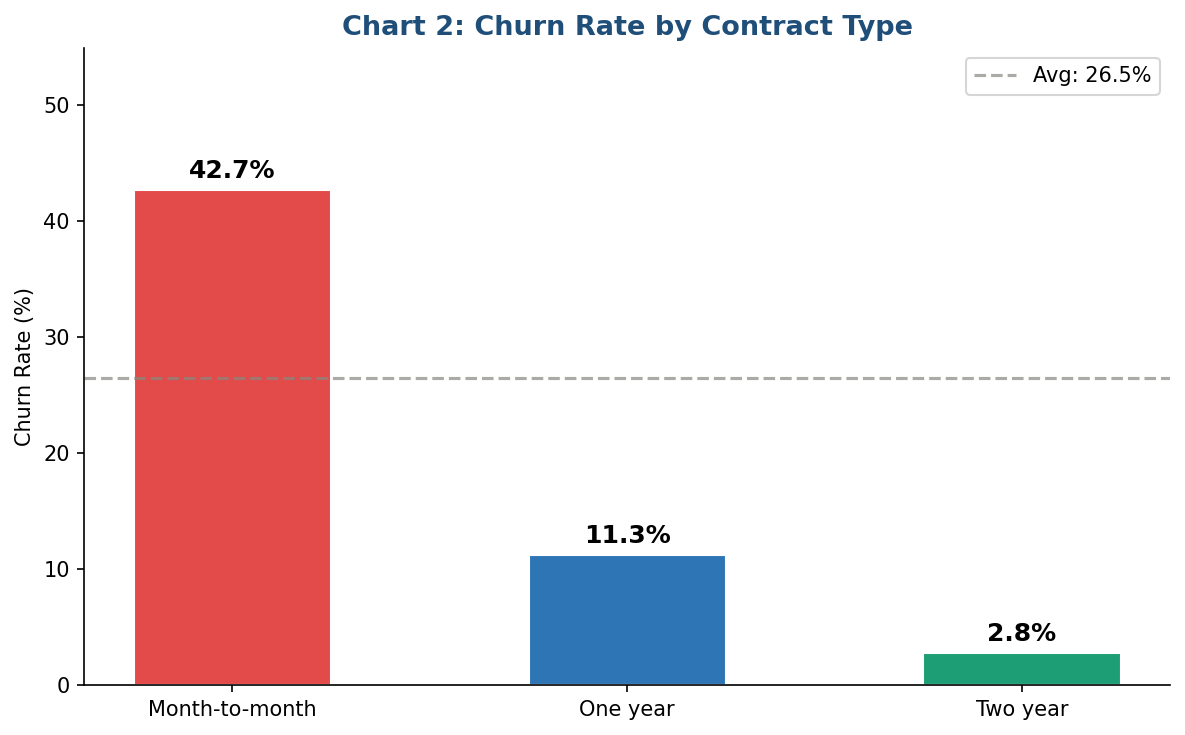

Chart 2 saved!


In [4]:
contract_churn = df.groupby('Contract')['Churn_Flag'].mean().reset_index()
contract_churn['churn_pct'] = contract_churn['Churn_Flag'] * 100
contract_churn['color'] = [RED, LBLUE, TEAL]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(contract_churn['Contract'], contract_churn['churn_pct'],
              color=contract_churn['color'], width=0.5, edgecolor='white')
ax.set_title('Chart 2: Churn Rate by Contract Type', fontsize=13,
             fontweight='bold', color=BLUE)
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)

for bar, val in zip(bars, contract_churn['churn_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.axhline(df['Churn_Flag'].mean()*100, color=GRAY, linestyle='--',
           alpha=0.7, label=f'Avg: {df["Churn_Flag"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig(BASE + r'\outputs\charts\02_churn_by_contract.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved!')

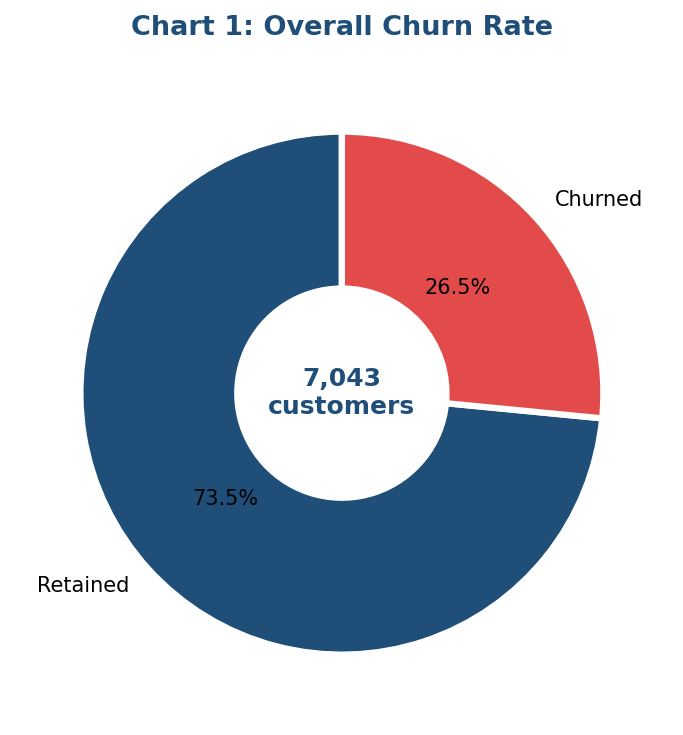

Chart 1 saved!


In [5]:
churn_counts = df['Churn'].value_counts()

fig, ax = plt.subplots(figsize=(7,5))
ax.pie(churn_counts, labels=['Retained','Churned'],
       colors=[BLUE, RED], autopct='%1.1f%%', startangle=90,
       wedgeprops={'width':0.6, 'edgecolor':'white', 'linewidth':3})
ax.text(0, 0, '7,043\ncustomers', ha='center', va='center',
        fontsize=12, fontweight='bold', color=BLUE)
ax.set_title('Chart 1: Overall Churn Rate', fontsize=13,
             fontweight='bold', color=BLUE, pad=15)
plt.tight_layout()
plt.savefig(BASE + r'\outputs\charts\01_churn_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved!')

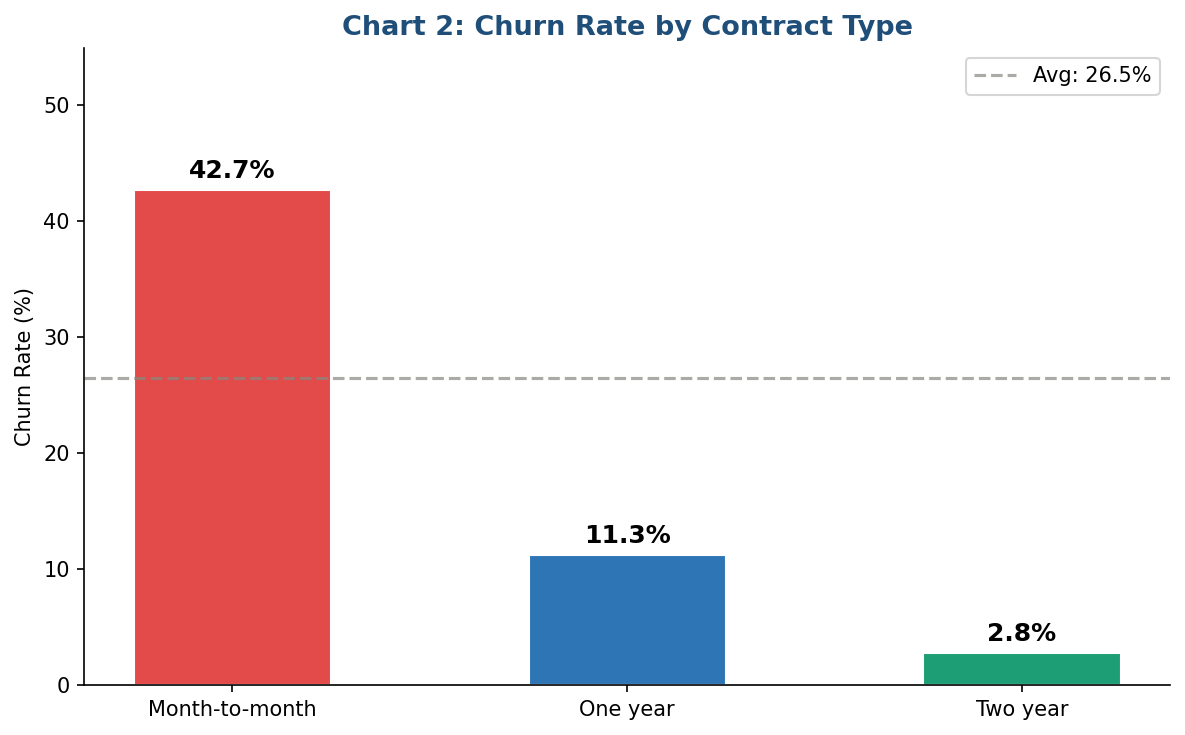

Chart 2 saved!


In [6]:
contract_churn = df.groupby('Contract')['Churn_Flag'].mean().reset_index()
contract_churn['churn_pct'] = contract_churn['Churn_Flag'] * 100
contract_churn['color'] = [RED, LBLUE, TEAL]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(contract_churn['Contract'], contract_churn['churn_pct'],
              color=contract_churn['color'], width=0.5, edgecolor='white')
ax.set_title('Chart 2: Churn Rate by Contract Type', fontsize=13,
             fontweight='bold', color=BLUE)
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)

for bar, val in zip(bars, contract_churn['churn_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.axhline(df['Churn_Flag'].mean()*100, color=GRAY, linestyle='--',
           alpha=0.7, label=f'Avg: {df["Churn_Flag"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig(BASE + r'\outputs\charts\02_churn_by_contract.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved!')

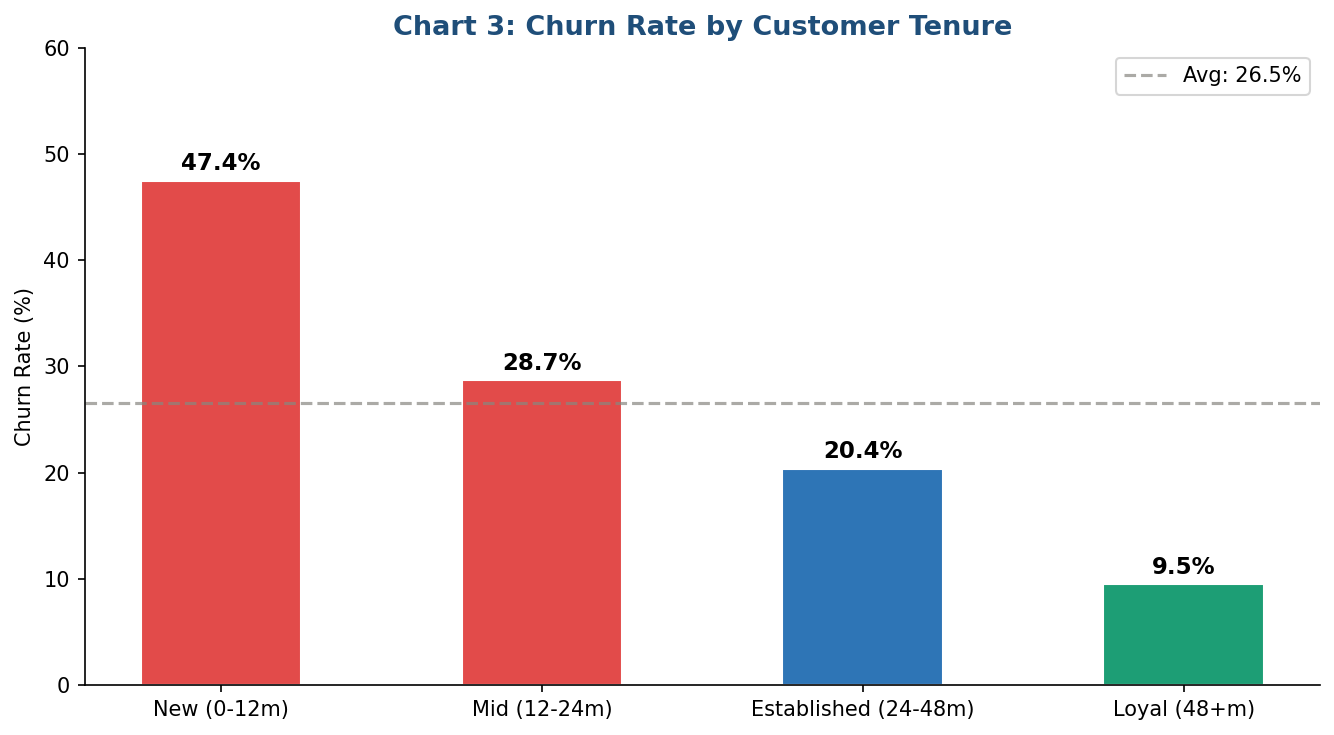

Chart 3 saved!


In [7]:
tenure_churn = df.groupby('TenureGroup', observed=True)['Churn_Flag'].mean()*100

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(tenure_churn.index, tenure_churn.values,
              color=[RED, RED, LBLUE, TEAL], width=0.5, edgecolor='white')
ax.set_title('Chart 3: Churn Rate by Customer Tenure',
             fontsize=13, fontweight='bold', color=BLUE)
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)

for bar, val in zip(bars, tenure_churn.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

ax.axhline(df['Churn_Flag'].mean()*100, color=GRAY, linestyle='--',
           alpha=0.7, label=f'Avg: {df["Churn_Flag"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig(BASE + r'\outputs\charts\03_churn_by_tenure.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved!')

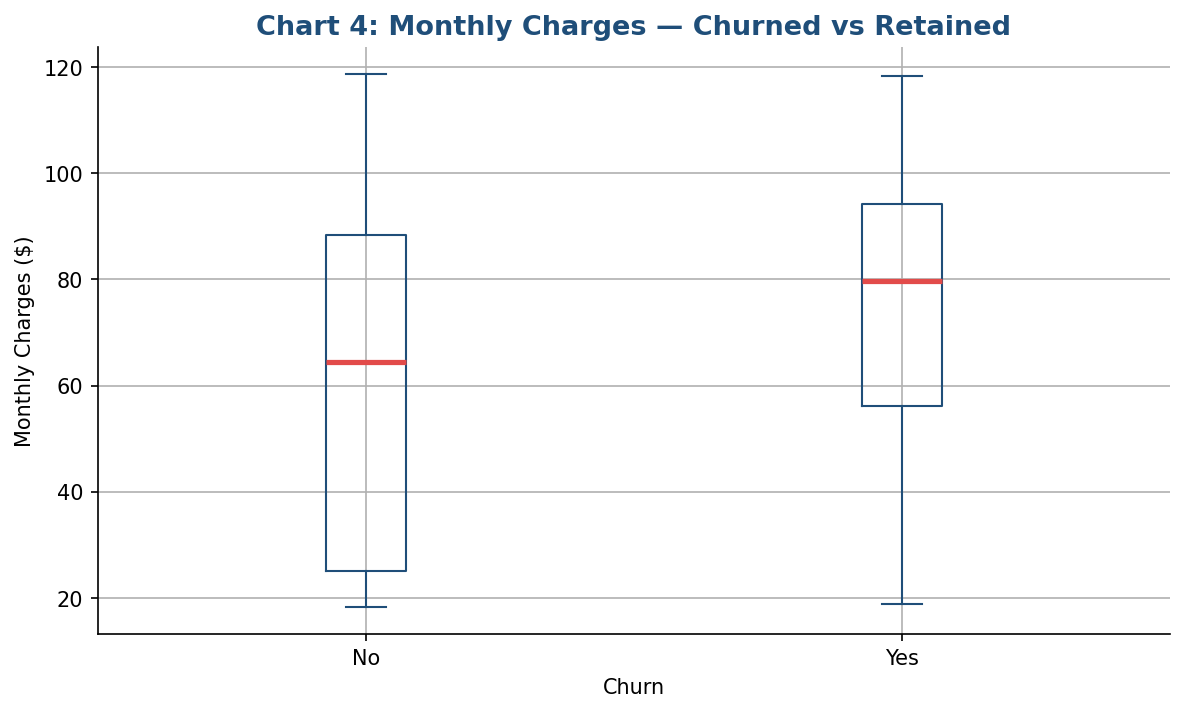

Chart 4 saved!


In [8]:
fig, ax = plt.subplots(figsize=(8,5))
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax,
           boxprops=dict(color=BLUE),
           medianprops=dict(color=RED, linewidth=2.5),
           whiskerprops=dict(color=BLUE),
           capprops=dict(color=BLUE))
ax.set_title('Chart 4: Monthly Charges — Churned vs Retained',
             fontsize=13, fontweight='bold', color=BLUE)
ax.set_xlabel('Churn')
ax.set_ylabel('Monthly Charges ($)')
plt.suptitle('')
plt.tight_layout()
plt.savefig(BASE + r'\outputs\charts\04_charges_boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved!')

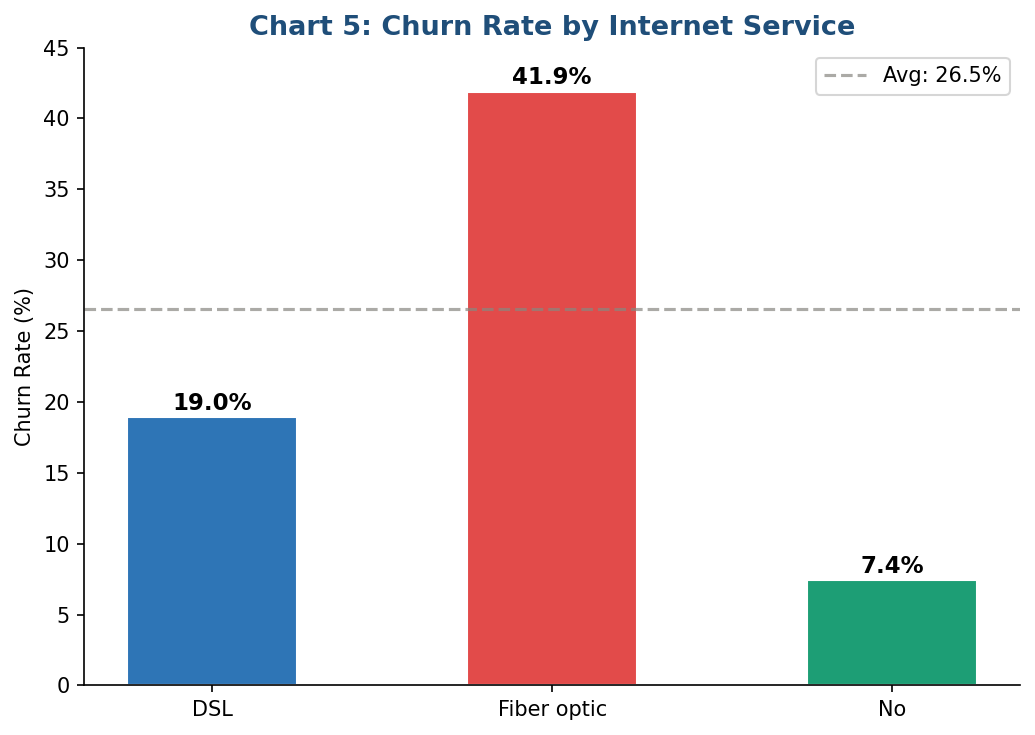

Chart 5 saved!


In [9]:
int_churn = df.groupby('InternetService')['Churn_Flag'].mean()*100

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(int_churn.index, int_churn.values,
              color=[LBLUE, RED, TEAL], width=0.5, edgecolor='white')
ax.set_title('Chart 5: Churn Rate by Internet Service',
             fontsize=13, fontweight='bold', color=BLUE)
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 45)

for bar, val in zip(bars, int_churn.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

ax.axhline(df['Churn_Flag'].mean()*100, color=GRAY, linestyle='--',
           alpha=0.7, label=f'Avg: {df["Churn_Flag"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig(BASE + r'\outputs\charts\05_churn_internet.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5 saved!')

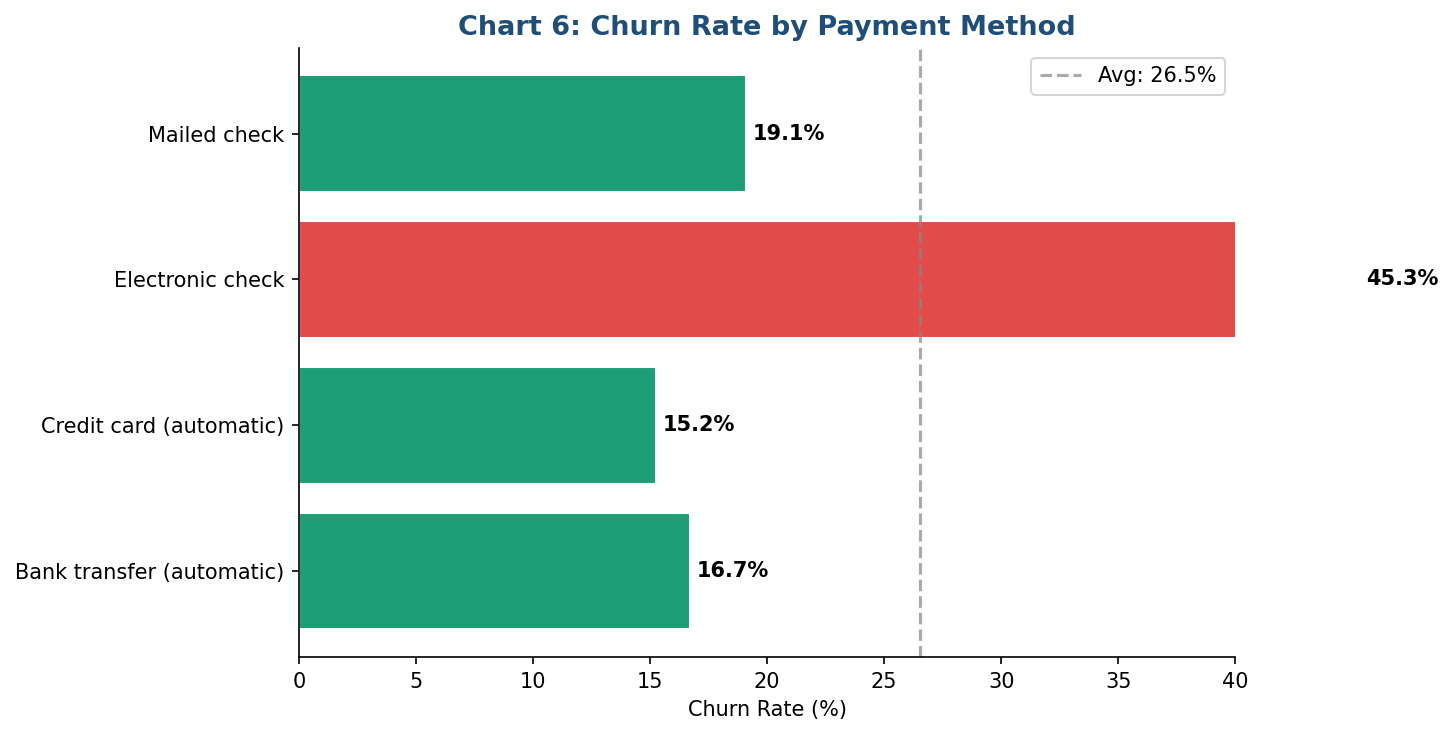

Chart 6 saved!


In [10]:
pay_churn = df.groupby('PaymentMethod')['Churn_Flag'].mean()*100

fig, ax = plt.subplots(figsize=(10,5))
colors_p = [TEAL, TEAL, RED, TEAL]
bars = ax.barh(pay_churn.index, pay_churn.values,
               color=colors_p, edgecolor='white')
ax.set_title('Chart 6: Churn Rate by Payment Method',
             fontsize=13, fontweight='bold', color=BLUE)
ax.set_xlabel('Churn Rate (%)')
ax.set_xlim(0, 40)

for bar, val in zip(bars, pay_churn.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)

ax.axvline(df['Churn_Flag'].mean()*100, color=GRAY, linestyle='--',
           alpha=0.7, label=f'Avg: {df["Churn_Flag"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig(BASE + r'\outputs\charts\06_churn_payment.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6 saved!')

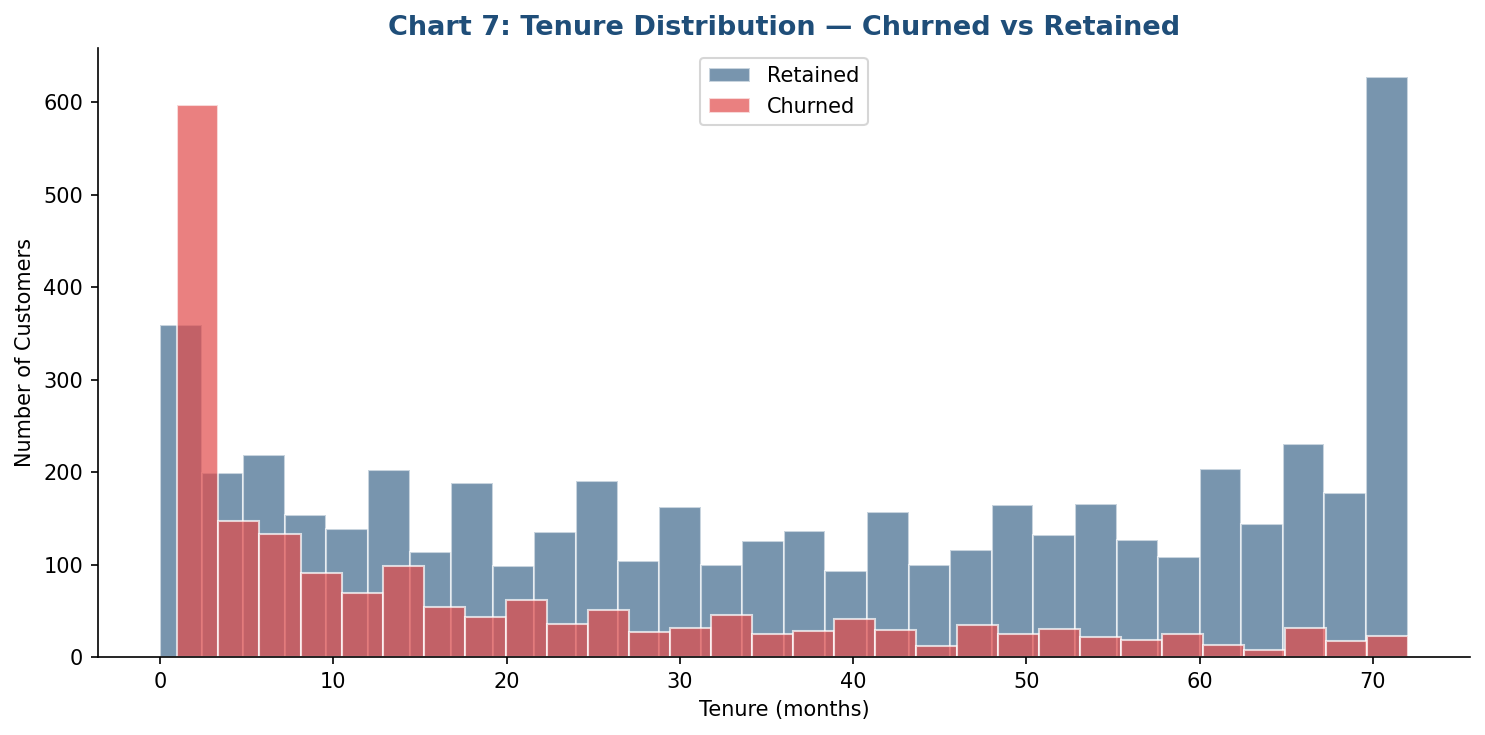

Chart 7 saved!


In [11]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(df[df['Churn']=='No']['tenure'], bins=30,
        color=BLUE, alpha=0.6, label='Retained', edgecolor='white')
ax.hist(df[df['Churn']=='Yes']['tenure'], bins=30,
        color=RED, alpha=0.7, label='Churned', edgecolor='white')
ax.set_title('Chart 7: Tenure Distribution — Churned vs Retained',
             fontsize=13, fontweight='bold', color=BLUE)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.savefig(BASE + r'\outputs\charts\07_tenure_histogram.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 7 saved!')

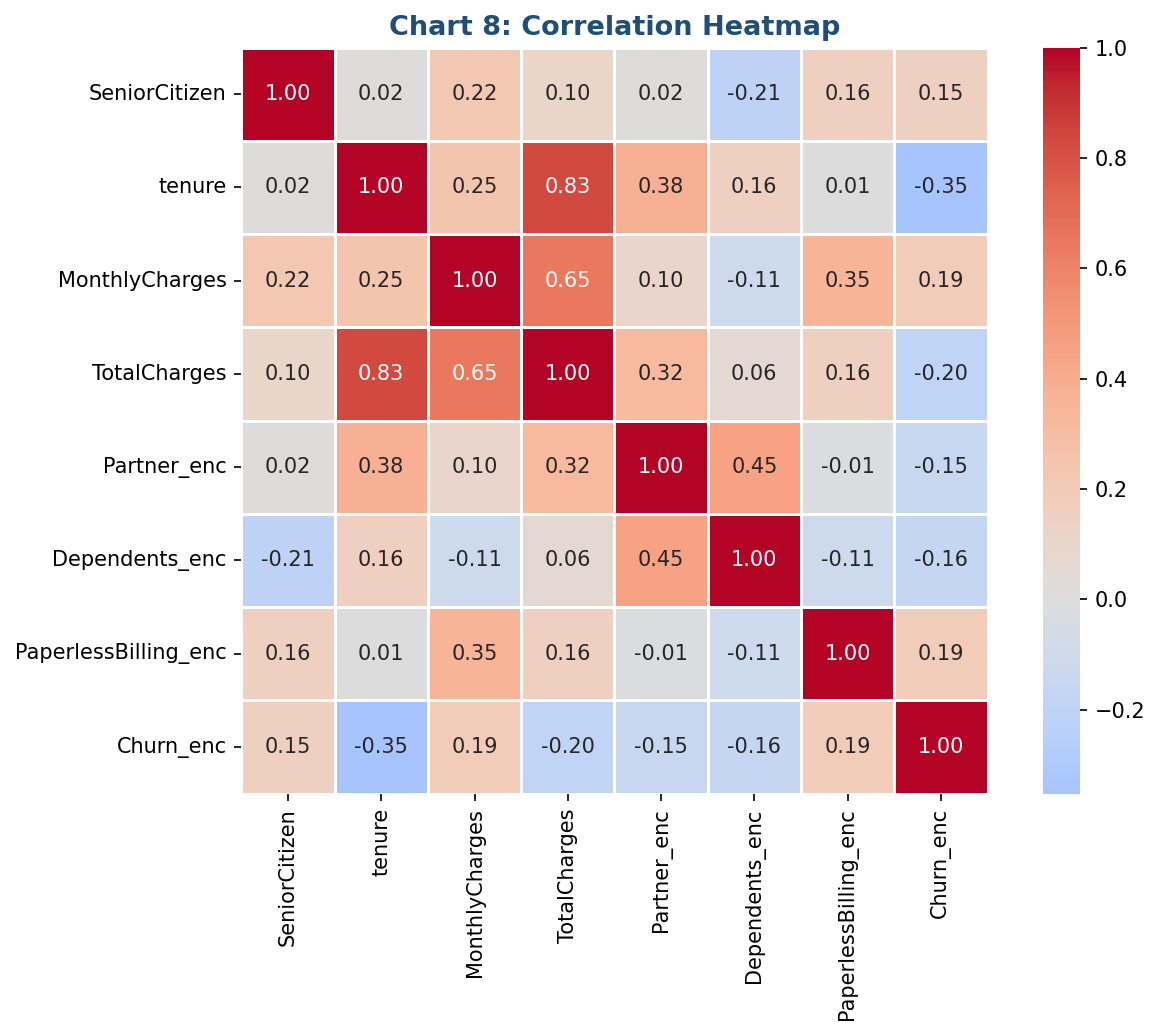

Chart 8 saved!


In [12]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
df_enc = df.copy()
for col in binary_cols:
    df_enc[col+'_enc'] = (df_enc[col]=='Yes').astype(int)

features = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges',
            'Partner_enc','Dependents_enc','PaperlessBilling_enc','Churn_enc']
corr = df_enc[features].corr()

fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True)
ax.set_title('Chart 8: Correlation Heatmap',
             fontsize=13, fontweight='bold', color=BLUE)
plt.tight_layout()
plt.savefig(BASE + r'\outputs\charts\08_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 8 saved!')

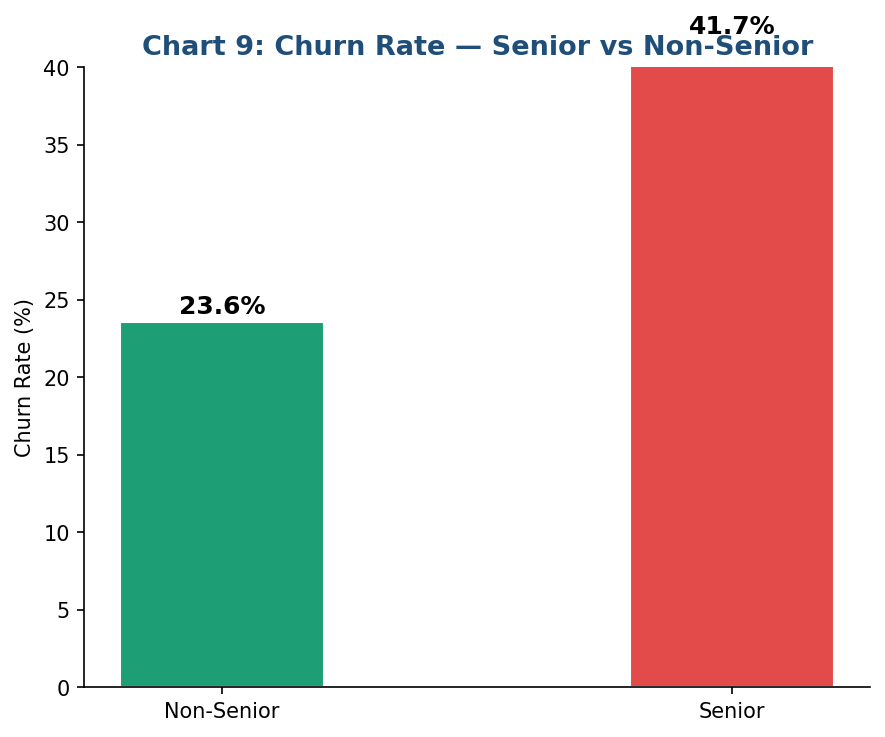

Chart 9 saved!


In [14]:
senior = df.groupby('SeniorCitizen')['Churn_Flag'].mean()*100

fig, ax = plt.subplots(figsize=(6,5))
bars = ax.bar(['Non-Senior','Senior'], senior.values,
              color=[TEAL, RED], width=0.4, edgecolor='white')
ax.set_title('Chart 9: Churn Rate — Senior vs Non-Senior',
             fontsize=13, fontweight='bold', color=BLUE)
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 40)

for bar, val in zip(bars, senior.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(BASE + r'\outputs\charts\09_senior_churn.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 9 saved!')

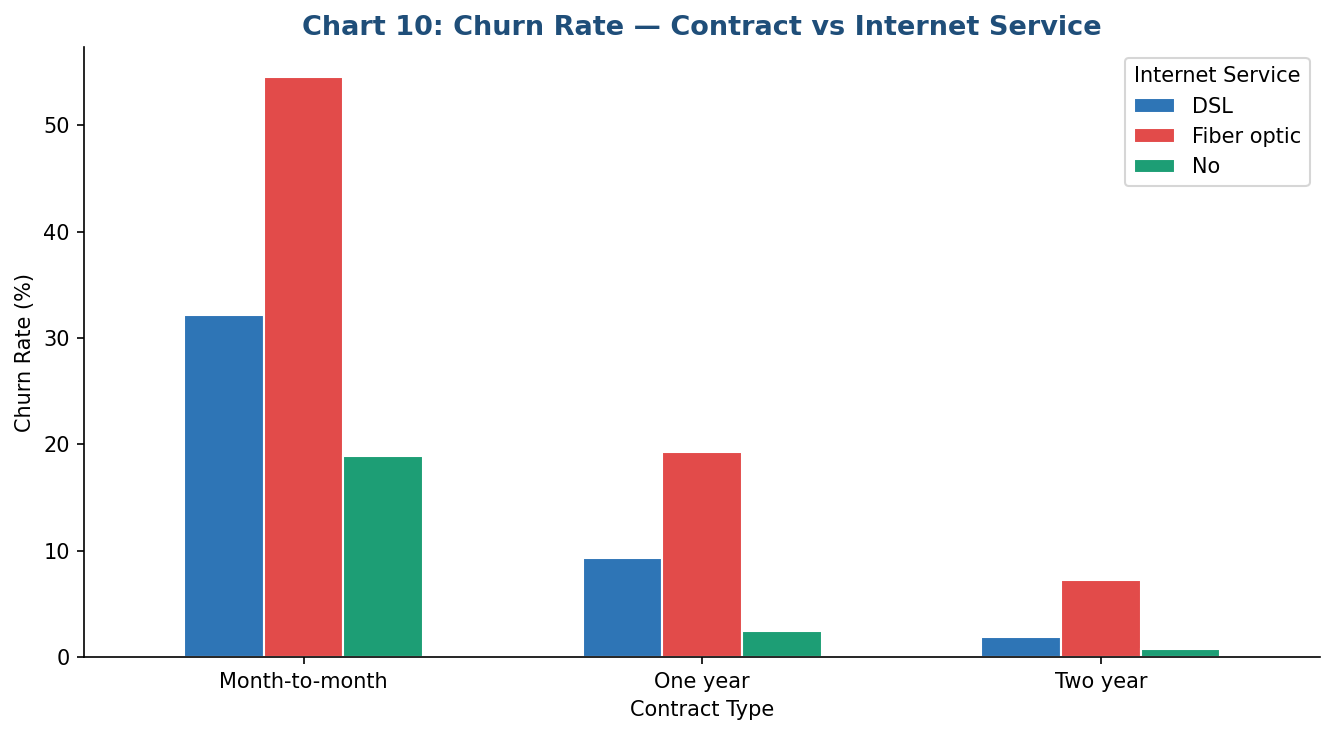

Chart 10 saved!


In [15]:
pivot = df.pivot_table(values='Churn_Flag', index='Contract',
                       columns='InternetService', aggfunc='mean')*100

fig, ax = plt.subplots(figsize=(9,5))
pivot.plot(kind='bar', ax=ax, color=[LBLUE, RED, TEAL],
           edgecolor='white', width=0.6)
ax.set_title('Chart 10: Churn Rate — Contract vs Internet Service',
             fontsize=13, fontweight='bold', color=BLUE)
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Contract Type')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Internet Service')
plt.tight_layout()
plt.savefig(BASE + r'\outputs\charts\10_contract_internet.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 10 saved!')

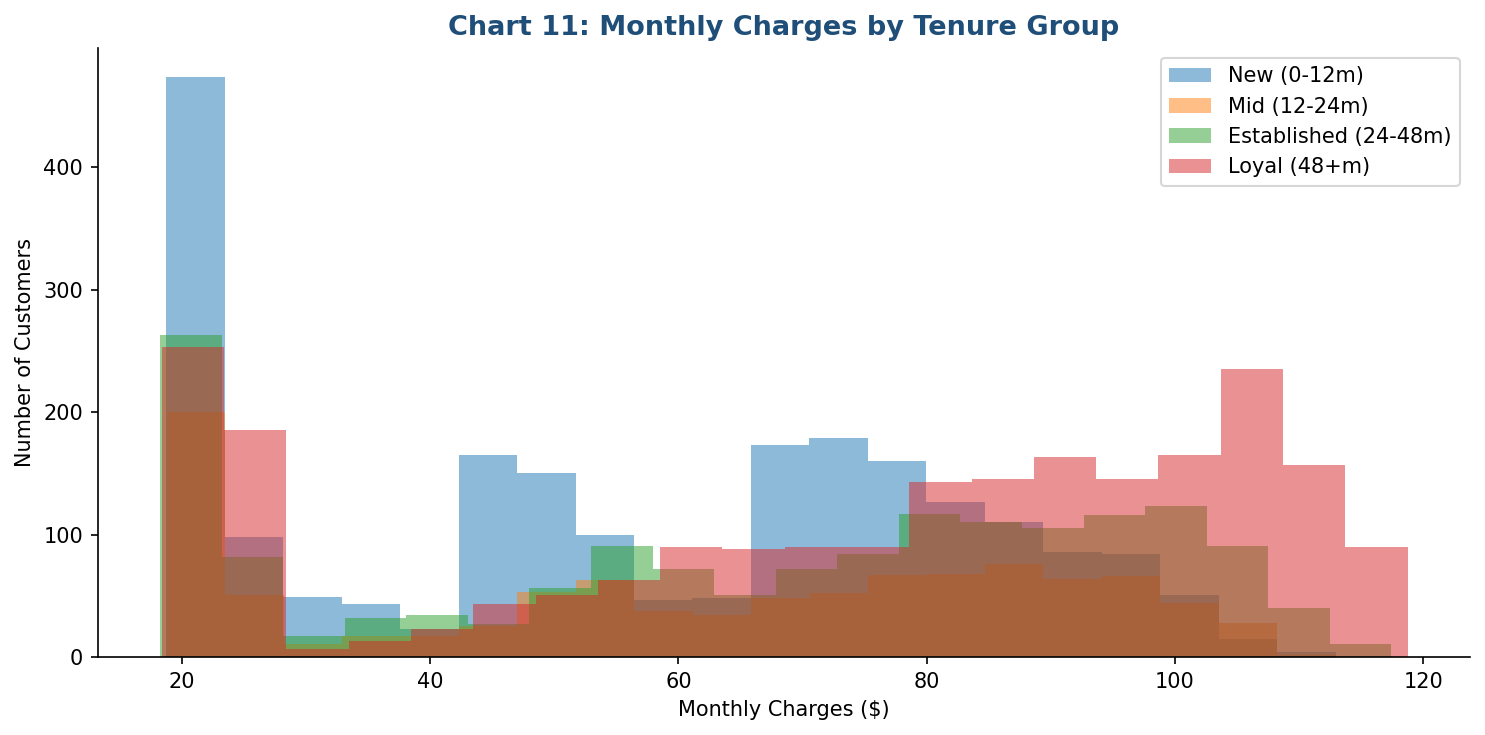

Chart 11 saved!


In [16]:
fig, ax = plt.subplots(figsize=(10,5))
groups = df['TenureGroup'].cat.categories
for grp in groups:
    data = df[df['TenureGroup']==grp]['MonthlyCharges']
    ax.hist(data, bins=20, alpha=0.5, label=grp, edgecolor='none')
ax.set_title('Chart 11: Monthly Charges by Tenure Group',
             fontsize=13, fontweight='bold', color=BLUE)
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.savefig(BASE + r'\outputs\charts\11_charges_tenure.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 11 saved!')

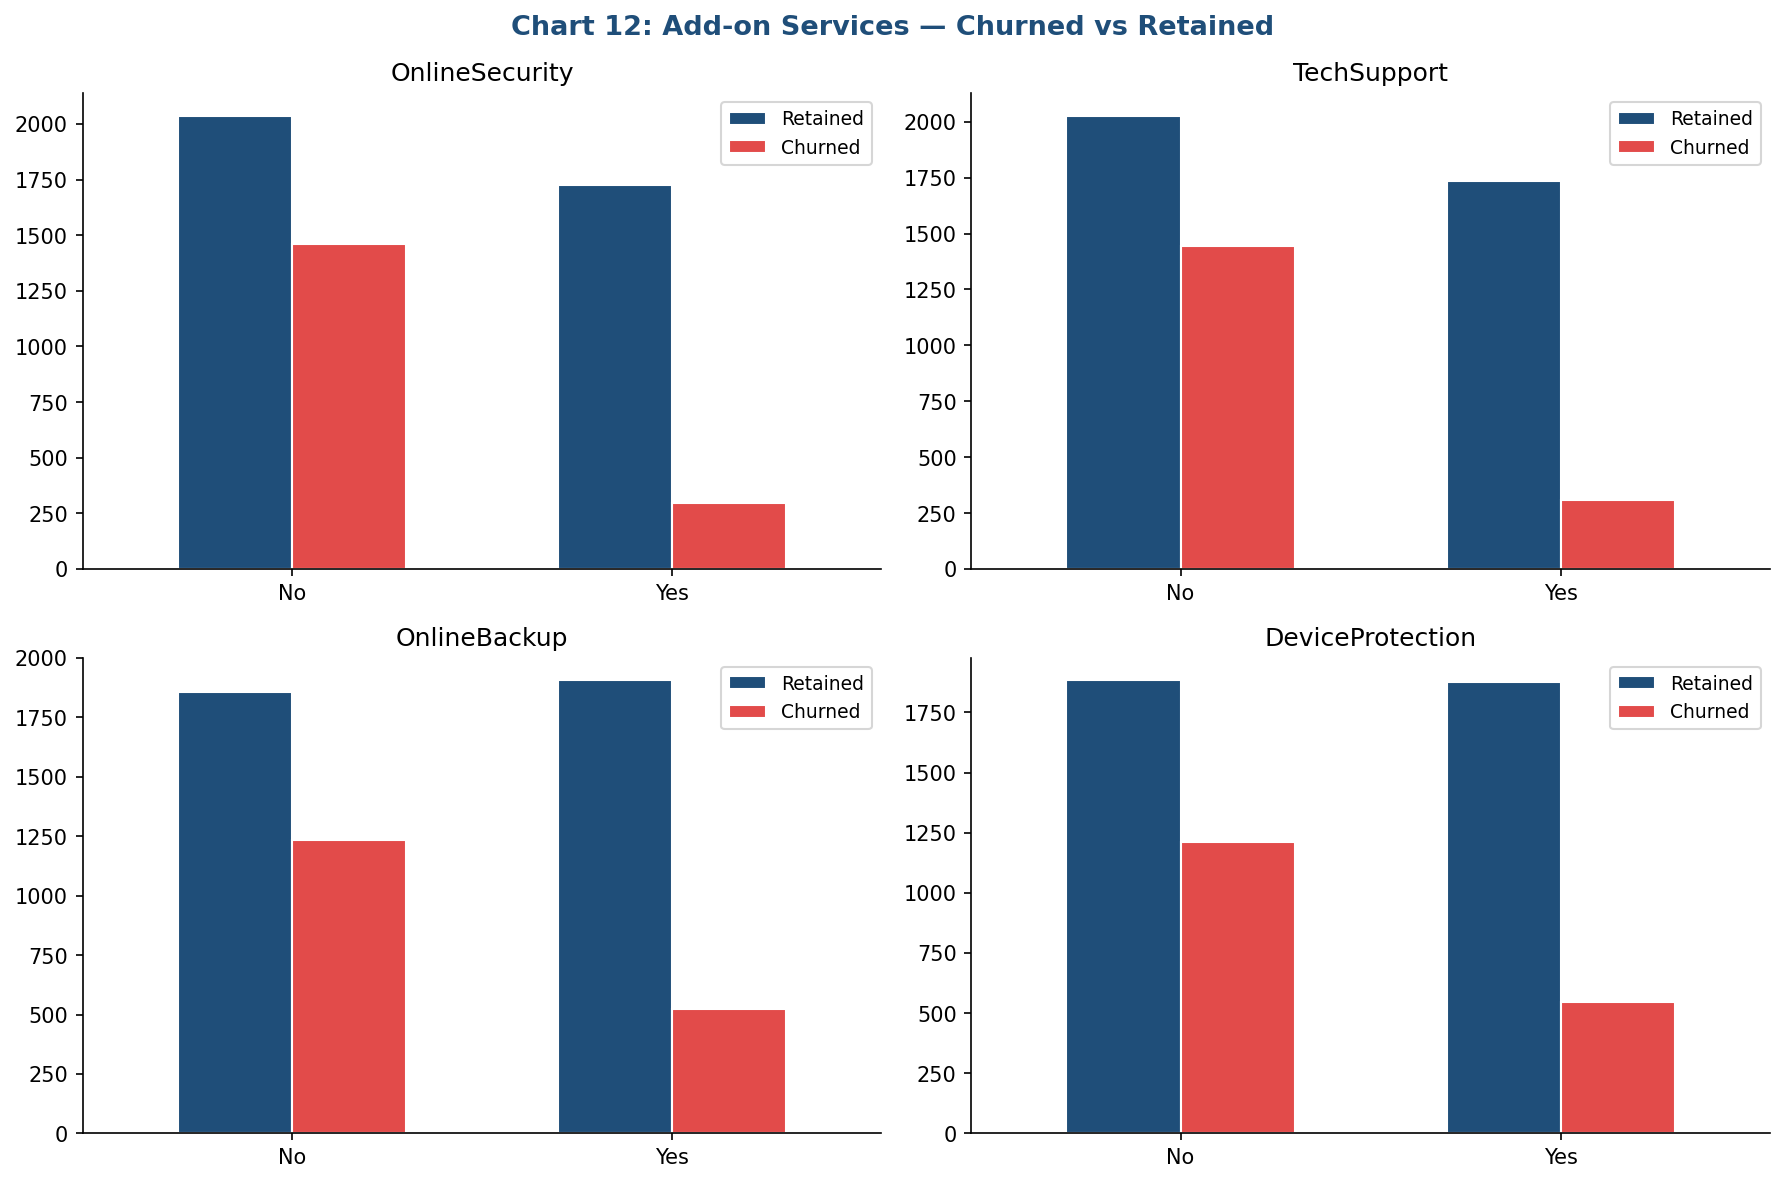

Chart 12 saved!


In [17]:
services = ['OnlineSecurity','TechSupport','OnlineBackup','DeviceProtection']
fig, axes = plt.subplots(2, 2, figsize=(12,8))
fig.suptitle('Chart 12: Add-on Services — Churned vs Retained',
             fontsize=13, fontweight='bold', color=BLUE)

for ax, col in zip(axes.flat, services):
    d = df[df[col].isin(['Yes','No'])]
    d.groupby([col,'Churn'])['customerID'].count().unstack().plot(
        kind='bar', ax=ax, color=[BLUE, RED],
        edgecolor='white', width=0.6)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(['Retained','Churned'], fontsize=9)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(BASE + r'\outputs\charts\12_services_churn.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 12 saved!')

In [18]:
from scipy.stats import chi2_contingency

# Chi-square test 1: Contract vs Churn
ct_contract = pd.crosstab(df['Contract'], df['Churn'])
chi2, p_val, dof, expected = chi2_contingency(ct_contract)

print('=== Chi-Square Test 1: Contract Type vs Churn ===')
print(f'Chi-square statistic : {chi2:.2f}')
print(f'P-value              : {p_val:.6f}')
print(f'Degrees of freedom   : {dof}')
print(f'Significant (p<0.05) : {p_val < 0.05}')
print()
if p_val < 0.05:
    print('CONCLUSION: Contract type SIGNIFICANTLY affects churn.')
    print('Month-to-month customers churn at 41% vs 3% for Two-year.')
    print('This is a REAL difference, not random chance.')

print()

# Chi-square test 2: Internet Service vs Churn
ct_internet = pd.crosstab(df['InternetService'], df['Churn'])
chi2_i, p_i, dof_i, _ = chi2_contingency(ct_internet)

print('=== Chi-Square Test 2: Internet Service vs Churn ===')
print(f'Chi-square statistic : {chi2_i:.2f}')
print(f'P-value              : {p_i:.6f}')
print(f'Significant (p<0.05) : {p_i < 0.05}')

print()

# Chi-square test 3: Payment Method vs Churn
ct_payment = pd.crosstab(df['PaymentMethod'], df['Churn'])
chi2_p, p_p, dof_p, _ = chi2_contingency(ct_payment)

print('=== Chi-Square Test 3: Payment Method vs Churn ===')
print(f'Chi-square statistic : {chi2_p:.2f}')
print(f'P-value              : {p_p:.6f}')
print(f'Significant (p<0.05) : {p_p < 0.05}')

print()

# Summary table
print('=== SUMMARY OF ALL CHI-SQUARE TESTS ===')
results = pd.DataFrame({
    'Variable'    : ['Contract Type', 'Internet Service', 'Payment Method'],
    'Chi2'        : [round(chi2,2), round(chi2_i,2), round(chi2_p,2)],
    'P-Value'     : [round(p_val,6), round(p_i,6), round(p_p,6)],
    'Significant' : ['Yes' if p_val<0.05 else 'No',
                     'Yes' if p_i<0.05 else 'No',
                     'Yes' if p_p<0.05 else 'No']
})
print(results.to_string(index=False))

=== Chi-Square Test 1: Contract Type vs Churn ===
Chi-square statistic : 1184.60
P-value              : 0.000000
Degrees of freedom   : 2
Significant (p<0.05) : True

CONCLUSION: Contract type SIGNIFICANTLY affects churn.
Month-to-month customers churn at 41% vs 3% for Two-year.
This is a REAL difference, not random chance.

=== Chi-Square Test 2: Internet Service vs Churn ===
Chi-square statistic : 732.31
P-value              : 0.000000
Significant (p<0.05) : True

=== Chi-Square Test 3: Payment Method vs Churn ===
Chi-square statistic : 648.14
P-value              : 0.000000
Significant (p<0.05) : True

=== SUMMARY OF ALL CHI-SQUARE TESTS ===
        Variable    Chi2  P-Value Significant
   Contract Type 1184.60      0.0         Yes
Internet Service  732.31      0.0         Yes
  Payment Method  648.14      0.0         Yes


In [21]:
=== Correlation with Churn ===
tenure           -0.352
MonthlyCharges    0.193
TotalCharges     -0.199

=== Interpretation ===
tenure vs Churn        : -0.352
  Longer tenure = LESS likely to churn (negative = good)

MonthlyCharges vs Churn: 0.193
  Higher bills = slightly MORE likely to churn

TotalCharges vs Churn  : -0.199
  Higher total charges = LESS likely to churn
  Because loyal long-term customers accumulate high total charges

SyntaxError: invalid syntax (868537979.py, line 1)